ข้อมูลเกี่ยวกับโค้ดชุดนี้
- Business Question
  - ปัจจัยใดที่สัมพันธ์กับกำไรต่ำ (เช่น ส่วนลดสูง หรือโครงสร้างสินค้าที่ซื้อ)? และควรให้ความสำคัญกับการปรับกลยุทธ์ onboarding ของกลุ่มใดก่อน
- Metric ที่โฟกัสในโค้ดนี้
  - clv_proxy, recency_days, frequency, discount_sensitivity, customer_segment


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("abt_project2.csv")

In [ ]:
df.describe()

,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,clv_proxy
count,2256.000000,2256.000000,2256.000000,2256.000000,2256.000000,2256.000000,2256.000000
mean,6.028812,101.733599,541.064273,9946.954486,1468.574300,0.247340,5540.680417
std,2.293646,99.407007,207.148716,8693.342155,618.271722,0.431562,4460.671775
min,1.000000,1.000000,180.000000,660.350000,315.790000,0.000000,348.180000
25%,4.000000,23.000000,362.000000,4945.350000,1060.992500,0.000000,2472.992500
50%,6.000000,58.000000,546.000000,7570.925000,1316.440000,0.000000,4183.825000
75%,7.000000,160.000000,720.250000,12552.210000,1689.307500,0.000000,7276.212500
max,16.000000,359.000000,899.000000,155337.800000,4779.210000,1.000000,46080.300000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2256 entries, 0 to 2255
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           2256 non-null   object 
 1   region                2256 non-null   object 
 2   customer_segment      2256 non-null   object 
 3   discount_sensitivity  2256 non-null   object 
 4   frequency             2256 non-null   int64  
 5   recency_days          2256 non-null   int64  
 6   tenure_days           2256 non-null   int64  
 7   monetary              2256 non-null   float64
 8   avg_spend             2256 non-null   float64
 9   churn_flag            2256 non-null   int64  
 10  clv_proxy             2256 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 194.0+ KB


In [ ]:
df.head()

,customer_id,region,customer_segment,discount_sensitivity,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,clv_proxy
0,C00001,Central,High Activity,Low,8,158,389,9235.30,1154.41,0,3996.13
1,C00002,East,Mid Activity,Low,6,20,742,14275.56,2379.26,1,11782.50
2,C00003,South,Mid Activity,Low,5,7,297,5947.43,1189.49,0,1964.84
3,C00004,South,Low Activity,Low,4,249,892,6167.41,1541.85,1,6119.38
4,C00005,North,High Activity,Low,8,120,556,10749.66,1343.71,0,6648.30


In [ ]:
df.columns

Index(['customer_id', 'region', 'customer_segment', 'discount_sensitivity',
       'frequency', 'recency_days', 'tenure_days', 'monetary', 'avg_spend',
       'churn_flag', 'clv_proxy'],
      dtype='object')

In [ ]:
df_metric = df[[
    "customer_segment",
    "frequency",
    "clv_proxy",
    "recency_days",
    "discount_sensitivity"
]]

In [ ]:
print(df_metric)

     customer_segment  frequency  clv_proxy  recency_days discount_sensitivity
0       High Activity          8    3996.13           158                  Low
1        Mid Activity          6   11782.50            20                  Low
2        Mid Activity          5    1964.84             7                  Low
3        Low Activity          4    6119.38           249                  Low
4       High Activity          8    6648.30           120                  Low
...               ...        ...        ...           ...                  ...
2251       Power User          9   11633.00             9                  Low
2252     Low Activity          3    1710.93            23                  Low
2253    High Activity          7   12939.61             4                  Low
2254    High Activity          8    3816.91            40                 High
2255     Low Activity          4    3280.20            24                 High

[2256 rows x 5 columns]


In [ ]:
df_metric.isna().sum()

,0
customer_segment,0
frequency,0
clv_proxy,0
recency_days,0
discount_sensitivity,0


In [ ]:
df_metric.duplicated().sum()

np.int64(0)

In [ ]:
from google.colab import files
uploaded = files.upload()
uploaded.keys()

dict_keys([])

In [ ]:
df.head()

,customer_id,region,customer_segment,discount_sensitivity,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,clv_proxy
0,C00001,Central,High Activity,Low,8,158,389,9235.30,1154.41,0,3996.13
1,C00002,East,Mid Activity,Low,6,20,742,14275.56,2379.26,1,11782.50
2,C00003,South,Mid Activity,Low,5,7,297,5947.43,1189.49,0,1964.84
3,C00004,South,Low Activity,Low,4,249,892,6167.41,1541.85,1,6119.38
4,C00005,North,High Activity,Low,8,120,556,10749.66,1343.71,0,6648.30


In [ ]:
sensitivity_map = {'Low': 3, 'Medium': 2, 'High': 1}
df['sensitivity_score'] = df['discount_sensitivity'].map(sensitivity_map)

In [ ]:
df.head()

,customer_id,region,customer_segment,discount_sensitivity,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,clv_proxy,sensitivity_score
0,C00001,Central,High Activity,Low,8,158,389,9235.30,1154.41,0,3996.13,3
1,C00002,East,Mid Activity,Low,6,20,742,14275.56,2379.26,1,11782.50,3
2,C00003,South,Mid Activity,Low,5,7,297,5947.43,1189.49,0,1964.84,3
3,C00004,South,Low Activity,Low,4,249,892,6167.41,1541.85,1,6119.38,3
4,C00005,North,High Activity,Low,8,120,556,10749.66,1343.71,0,6648.30,3


In [ ]:
df['clv_proxy'].sort_values(ascending=False)

,clv_proxy
1847,46080.30
440,28400.50
2242,26112.13
1491,25910.24
756,25768.53
...,...
797,452.74
883,433.96
1881,411.24
1814,393.45


In [ ]:
def min_max_normalize(series, reverse=False):
    if reverse:
        return (series.max() - series) / (series.max() - series.min())
    return (series - series.min()) / (series.max() - series.min())

df['norm_clv'] = min_max_normalize(df['clv_proxy'])
df['norm_freq'] = min_max_normalize(df['frequency'])
df['norm_recency'] = min_max_normalize(df['recency_days'], reverse=True)
df['norm_sensitivity'] = min_max_normalize(df['sensitivity_score'])

In [ ]:
df.head()

,customer_id,region,customer_segment,discount_sensitivity,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,clv_proxy,sensitivity_score,norm_clv,norm_freq,norm_recency,norm_sensitivity
0,C00001,Central,High Activity,Low,8,158,389,9235.30,1154.41,0,3996.13,3,0.079768,0.466667,0.561453,1.0
1,C00002,East,Mid Activity,Low,6,20,742,14275.56,2379.26,1,11782.50,3,0.250028,0.333333,0.946927,1.0
2,C00003,South,Mid Activity,Low,5,7,297,5947.43,1189.49,0,1964.84,3,0.035351,0.266667,0.983240,1.0
3,C00004,South,Low Activity,Low,4,249,892,6167.41,1541.85,1,6119.38,3,0.126196,0.200000,0.307263,1.0
4,C00005,North,High Activity,Low,8,120,556,10749.66,1343.71,0,6648.30,3,0.137761,0.466667,0.667598,1.0


In [ ]:
def label_group(frequency):
    return 'High Frq' if frequency >= 5 else 'Low Frq'

df['freq_segment'] = df['frequency'].apply(label_group)

In [ ]:
df['longevity_score'] = (
    (df['norm_clv'] * 0.20) +
    (df['norm_freq'] * 0.70) +
    (df['norm_recency'] * 0.05) +
    (df['norm_sensitivity'] * 0.05)
)

In [ ]:
df['fomo_score'] = (
    (df['norm_clv'] * 0.10) +
    (df['norm_freq'] * 0.05) +
    (df['norm_recency'] * 0.05) +
    (df['norm_sensitivity'] * 0.80)
)

In [ ]:
labels = ['Low Longevity', 'Mid Longevity', 'High Longevity']
df['longevity_segment'] = pd.qcut(df['longevity_score'], q=3, labels=labels)

In [ ]:
labels = ['Low Longevity', 'Mid Longevity', 'High Longevity']
df['longevity_segment3'] = pd.qcut(df['longevity_score'], q=3, labels=labels)

In [ ]:
df['longevity_segment2'] = pd.cut(df['longevity_score'], bins=3, right=True, labels=labels)

In [ ]:
labels2 = ['Low fomo', 'Mid fomo', 'High fomo']
df['fomo_segment'] = pd.cut(df['fomo_score'], bins=3, right=True, labels=labels2)

In [ ]:
df.head()

,customer_id,region,customer_segment,discount_sensitivity,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,...,norm_freq,norm_recency,norm_sensitivity,freq_segment,longevity_score,fomo_score,longevity_segment,longevity_segment3,longevity_segment2,fomo_segment
0,C00001,Central,High Activity,Low,8,158,389,9235.30,1154.41,0,...,0.466667,0.561453,1.0,High Frq,0.420693,0.859383,High Longevity,High Longevity,Mid Longevity,High fomo
1,C00002,East,Mid Activity,Low,6,20,742,14275.56,2379.26,1,...,0.333333,0.946927,1.0,High Frq,0.380685,0.889016,High Longevity,High Longevity,Mid Longevity,High fomo
2,C00003,South,Mid Activity,Low,5,7,297,5947.43,1189.49,0,...,0.266667,0.983240,1.0,High Frq,0.292899,0.866030,Mid Longevity,Mid Longevity,Low Longevity,High fomo
3,C00004,South,Low Activity,Low,4,249,892,6167.41,1541.85,1,...,0.200000,0.307263,1.0,Low Frq,0.230602,0.837983,Low Longevity,Low Longevity,Low Longevity,High fomo
4,C00005,North,High Activity,Low,8,120,556,10749.66,1343.71,0,...,0.466667,0.667598,1.0,High Frq,0.437599,0.870489,High Longevity,High Longevity,Mid Longevity,High fomo


In [ ]:
df.groupby('longevity_segment').agg({'customer_id': 'nunique',
                                     'clv_proxy': ['mean','max'],
                                     'recency_days':'mean'} )

/tmp/ipython-input-499379925.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('longevity_segment').agg({'customer_id': 'nunique',


customer_id    clv_proxy           recency_days
                      nunique         mean       max         mean
longevity_segment                                                
Low Longevity             752  2621.129508   8419.26   114.170213
Mid Longevity             752  4841.622154  18844.01   108.734043
High Longevity            752  9159.289588  46080.30    82.296543

In [ ]:
df.groupby('longevity_segment2').agg({'customer_id': 'nunique',
                                     'clv_proxy': ['mean','max'],
                                     'recency_days':'mean'} )

/tmp/ipython-input-3144562484.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('longevity_segment2').agg({'customer_id': 'nunique',


customer_id     clv_proxy           recency_days
                       nunique          mean       max         mean
longevity_segment2                                                 
Low Longevity             1028   2830.451060   8419.26   112.397860
Mid Longevity             1165   7432.950326  25910.24    93.181974
High Longevity              63  14772.765079  46080.30    85.857143

In [ ]:
df.groupby(['fomo_segment','freq_segment']).agg({'customer_id': 'nunique',
                                     'clv_proxy': ['mean','max']})

/tmp/ipython-input-3077760414.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['fomo_segment','freq_segment']).agg({'customer_id': 'nunique',


customer_id    clv_proxy          
                              nunique         mean       max
fomo_segment freq_segment                                   
Low fomo     High Frq             436  6209.205115  25768.53
             Low Frq              147  2494.795986   6539.69
Mid fomo     High Frq               0          NaN       NaN
             Low Frq                0          NaN       NaN
High fomo    High Frq            1204  6891.672591  46080.30
             Low Frq              469  2405.656247   6119.38

In [ ]:
df

,customer_id,region,customer_segment,discount_sensitivity,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,...,norm_freq,norm_recency,norm_sensitivity,freq_segment,longevity_score,fomo_score,longevity_segment,longevity_segment3,longevity_segment2,fomo_segment
0,C00001,Central,High Activity,Low,8,158,389,9235.30,1154.41,0,...,0.466667,0.561453,1.0,High Frq,0.420693,0.859383,High Longevity,High Longevity,Mid Longevity,High fomo
1,C00002,East,Mid Activity,Low,6,20,742,14275.56,2379.26,1,...,0.333333,0.946927,1.0,High Frq,0.380685,0.889016,High Longevity,High Longevity,Mid Longevity,High fomo
2,C00003,South,Mid Activity,Low,5,7,297,5947.43,1189.49,0,...,0.266667,0.983240,1.0,High Frq,0.292899,0.866030,Mid Longevity,Mid Longevity,Low Longevity,High fomo
3,C00004,South,Low Activity,Low,4,249,892,6167.41,1541.85,1,...,0.200000,0.307263,1.0,Low Frq,0.230602,0.837983,Low Longevity,Low Longevity,Low Longevity,High fomo
4,C00005,North,High Activity,Low,8,120,556,10749.66,1343.71,0,...,0.466667,0.667598,1.0,High Frq,0.437599,0.870489,High Longevity,High Longevity,Mid Longevity,High fomo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2251,C02346,South,Power User,Low,9,9,326,32080.00,3564.44,0,...,0.533333,0.977654,1.0,High Frq,0.521568,0.900225,High Longevity,High Longevity,Mid Longevity,High fomo
2252,C02347,South,Low Activity,Low,3,23,669,2299.13,766.38,0,...,0.133333,0.938547,1.0,Low Frq,0.196220,0.856574,Low Longevity,Low Longevity,Low Longevity,High fomo
2253,C02348,Central,High Activity,Low,7,4,657,17705.80,2529.40,1,...,0.400000,0.991620,1.0,High Frq,0.434647,0.897114,High Longevity,High Longevity,Mid Longevity,High fomo
2254,C02349,South,High Activity,High,8,40,338,10152.04,1269.01,0,...,0.466667,0.891061,0.0,High Frq,0.386390,0.075471,High Longevity,High Longevity,Mid Longevity,Low fomo


In [ ]:
df[df['fomo_segment']=='Low fomo'][['customer_id','clv_proxy','frequency']]

,customer_id,clv_proxy,frequency
9,C00010,11582.65,6
20,C00021,4995.18,4
23,C00024,6596.76,7
25,C00026,5685.04,4
27,C00028,2262.63,5
...,...,...,...
2240,C02334,5020.68,4
2243,C02337,5260.16,5
2249,C02344,6803.15,6
2254,C02349,3816.91,8


มุมมองทาง Business ทั้งหมดที่สามารถสร้าง Segmentation ได้


1.   **Discount × Basket Size Segment**
-> ใช้ discount_sensitivity + avg_spend
-> ตอบคำถามว่า กำไรต่ำเพราะ “ติดโปร” หรือ “ซื้อครั้งละน้อย”
2.   **Frequency × Avg Spend (โครงสร้างการซื้อ)**
-> ใช้ frequency + avg_spend
-> ตอบคำถามว่า กำไรหายเพราะ cost ต่อ order ไหม

1.   **Lifecycle × Profit Outcome**
-> ใช้ tenure_days + clv_proxy
-> ตอบคำถามว่า ปัญหาเกิด “ตั้งแต่ onboarding” หรือ “สายไปแล้ว” ควรแก้เมื่อไหร่
2.   **Active Cost Drain Segment**
-> ใช้ churn_flag + frequency + avg_spend + clv_proxy
-> ตอบคำถามว่า ใครยัง active แต่ดูดกำไร

มุมมองเสริม


1.   **Price–Volume Trap Segment**
-> ใช้ frequency × avg_spend × discount_sensitivity
-> ตอบคำถามว่า ลูกค้าที่ ซื้อเยอะเพราะโปร กำลังทำลาย margin ไหม
2.   **Early Habit Formation Segment**
-> ใช้ tenure_days × frequency × avg_spend
-> ตอบคำถามว่า ลูกค้า “นิสัยซื้อแบบนี้” เกิดตั้งแต่ช่วงแรกไหม


1.   **Silent Margin Killer Segment**
-> ใช้ active + low CLV + high frequency
-> ตอบคำถามว่า ใครไม่ churn ไม่โวย แต่ค่อยๆ ดูดกำไร? (ลูกค้าประจำที่กำลังกัดกำไรเงียบๆ)
2.   **Upside Potential Segment**
-> ใช้ low avg_spend × high CLV trend / high tenure
-> ตอบคำถามว่า ใครยังไม่จ่ายเยอะ “แต่มีศักยภาพ”? (กำไรต่ำเพราะ “ยังไม่โต” ไม่ใช่เพราะพฤติกรรมแย่)
3.  **Misaligned Incentive Segment**
-> ใช้ discount_sensitivity × churn_flag
-> ตอบคำถามว่า ลูกค้าที่ให้โปรไป…อยู่ต่อจริงไหม? (โปรช่วย retention จริงไหม หรือแค่ถ่วงเวลา)





เริ่มจากมุมมอง

1.   **Discount × Basket Size Segment**
-> ใช้ discount_sensitivity + avg_spend
-> ตอบคำถามว่า กำไรต่ำเพราะ “ติดโปร” หรือ “ซื้อครั้งละน้อย”

-> สร้าง Columns เพิ่ม 2 Columns เพื่อแบ่ง Segmentation ตาม **discount_sensitivity** และ **avg_spend**



In [ ]:
df["discount_level"] = df["discount_sensitivity"]


In [ ]:
df["spend_level"] = pd.qcut(df["avg_spend"], q=3, labels=["Low", "Mid", "High"])

In [ ]:
df.head()

,customer_id,region,customer_segment,discount_sensitivity,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,...,norm_sensitivity,freq_segment,longevity_score,fomo_score,longevity_segment,longevity_segment3,longevity_segment2,fomo_segment,discount_level,spend_level
0,C00001,Central,High Activity,Low,8,158,389,9235.30,1154.41,0,...,1.0,High Frq,0.420693,0.859383,High Longevity,High Longevity,Mid Longevity,High fomo,Low,Mid
1,C00002,East,Mid Activity,Low,6,20,742,14275.56,2379.26,1,...,1.0,High Frq,0.380685,0.889016,High Longevity,High Longevity,Mid Longevity,High fomo,Low,High
2,C00003,South,Mid Activity,Low,5,7,297,5947.43,1189.49,0,...,1.0,High Frq,0.292899,0.866030,Mid Longevity,Mid Longevity,Low Longevity,High fomo,Low,Mid
3,C00004,South,Low Activity,Low,4,249,892,6167.41,1541.85,1,...,1.0,Low Frq,0.230602,0.837983,Low Longevity,Low Longevity,Low Longevity,High fomo,Low,High
4,C00005,North,High Activity,Low,8,120,556,10749.66,1343.71,0,...,1.0,High Frq,0.437599,0.870489,High Longevity,High Longevity,Mid Longevity,High fomo,Low,Mid


-> เอาชื่อของ **discount_level** และ **spend_level** มาต่อกัน เชื่อมด้วย _

In [ ]:
df["promo_behavior"] = (df["discount_level"].astype(str) + "_" + df["spend_level"].astype(str))

-> เพื่อให้ค่าใน Column มีความหมายสื่อถึง Business Logic จึงสร้าง Column ใหม่ขึ้นมาและตั้งชื่อใหม่โดยใช้ map เพื่อ map ชื่อจาก Column promo_behavior และทำการแทนค่าที่ spend_level เป็น Mid ทั้งหมดด้วยค่า "ไม่ต้องรีบทำ campaign"

In [ ]:
promo_name_map = {
    "High_Low": "ติดโปร มูลค่าออเดอร์ต่ำ",
    "High_High": "ติดโปร มูลค่าออเดอร์สูง",
    "Low_High": "ไม่ติดโปร มูลค่าออเดอร์สูง",
    "Low_Low": "ไม่ติดโปร มูลค่าออเดอร์ต่ำ"
}
df["promo_segment_name"] = df["promo_behavior"].map(promo_name_map)
df["promo_segment_name"] = df["promo_segment_name"].fillna("ไม่ต้องรีบทำ campaign")

In [ ]:
df.head()

,customer_id,region,customer_segment,discount_sensitivity,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,...,longevity_score,fomo_score,longevity_segment,longevity_segment3,longevity_segment2,fomo_segment,discount_level,spend_level,promo_behavior,promo_segment_name
0,C00001,Central,High Activity,Low,8,158,389,9235.30,1154.41,0,...,0.420693,0.859383,High Longevity,High Longevity,Mid Longevity,High fomo,Low,Mid,Low_Mid,ไม่ต้องรีบทำ campaign
1,C00002,East,Mid Activity,Low,6,20,742,14275.56,2379.26,1,...,0.380685,0.889016,High Longevity,High Longevity,Mid Longevity,High fomo,Low,High,Low_High,ไม่ติดโปร มูลค่าออเดอร์สูง
2,C00003,South,Mid Activity,Low,5,7,297,5947.43,1189.49,0,...,0.292899,0.866030,Mid Longevity,Mid Longevity,Low Longevity,High fomo,Low,Mid,Low_Mid,ไม่ต้องรีบทำ campaign
3,C00004,South,Low Activity,Low,4,249,892,6167.41,1541.85,1,...,0.230602,0.837983,Low Longevity,Low Longevity,Low Longevity,High fomo,Low,High,Low_High,ไม่ติดโปร มูลค่าออเดอร์สูง
4,C00005,North,High Activity,Low,8,120,556,10749.66,1343.71,0,...,0.437599,0.870489,High Longevity,High Longevity,Mid Longevity,High fomo,Low,Mid,Low_Mid,ไม่ต้องรีบทำ campaign


-> สร้าง Summary Table ที่ 1



In [ ]:
summary_one = df.groupby(["promo_segment_name"]).agg({"customer_id": "nunique", "clv_proxy": "mean", "avg_spend": "mean"})
summary_one

,customer_id,clv_proxy,avg_spend
promo_segment_name,,,
ติดโปร มูลค่าออเดอร์ต่ำ,211,3369.410095,932.594597
ติดโปร มูลค่าออเดอร์สูง,162,8697.983210,2161.536852
ไม่ติดโปร มูลค่าออเดอร์ต่ำ,541,3065.890628,922.728503
ไม่ติดโปร มูลค่าออเดอร์สูง,590,9176.906407,2156.169678
ไม่ต้องรีบทำ campaign,752,4397.253457,1322.900213


**สรุป Insight ที่ได้จาก Summary Table ที่ 1**


*   **ดูเฉพาะ Low Spend**
-> สังเกตได้ว่า "ติดโปร มูลค่าออเดอร์ต่ำ" มี CLV ต่างกับ แบบ "ไม่ติดโปร มูลค่าออเดอร์ต่ำ" แค่นิดเดียว แปลว่า ความสนใจในโปรโมชัน ไม่ใช่ตัวการหลัก ตัวปัญหาอาจจะเกิดจากการที่ซื้อครั้งละน้อย -> กำไรต่ำ ไม่ได้เกิดเพราะติดโปรอย่างเดียวแต่เกิดเพราะ โครงสร้างการซื้อ (basket size ต่ำ) -> ดังนั้นสิ่งที่ควร Take Action คือ เพิ่ม Basket Size ไม่ใช่ลดโปรโมชัน โดยอาจออกแบบโปรที่ "บังคับให้ซื้อเพิ่ม" เช่น ลด 100 บาท เมื่อซื้อครบ 1,200, ซื้อ 2 ชิ้น แถม 1, Free shipping เมื่อซื้อครบ X บาท
*   **ดูเฉพาะ High Spend**
-> สังเกตได้ว่า "ติดโปร มูลค่าออเดอร์สูง ที CLV ต่างกับแบบ "ไม่ติดโปร มูลค่าออเดอร์สูง" แค่นิดเดียว แปลว่า ลูกค้าบางคน “ชอบโปร แต่ก็จ่ายจริง” ดังนั้นอย่ารีบตัดโปรแบบเหมารวม

*   **ดู Mid Group**
-> CLV ประมาณ 4397 สำหรับ Mid Group สูงกว่า low spend ชัด ไม่ต้องรีบทำ Promotion
*   **Segment ที่น่าเป็นห่วง**
-> "ติดโปร มูลค่าออเดอร์ต่ำ"





**เจาะลึกลงไปอีก**
ลองเพิ่ม Frequency เข้าไปดู

In [ ]:
df.groupby("promo_segment_name")["frequency"].mean()

,frequency
promo_segment_name,
ติดโปร มูลค่าออเดอร์ต่ำ,5.905213
ติดโปร มูลค่าออเดอร์สูง,6.623457
ไม่ติดโปร มูลค่าออเดอร์ต่ำ,5.567468
ไม่ติดโปร มูลค่าออเดอร์สูง,6.957627
ไม่ต้องรีบทำ campaign,5.538564


-> จะเห็นว่า Frequency ไม่ต่างกันมาก ติดโปรกับไม่ติดโปรต่างกันนิดเดียว แปลว่า โปรไม่ได้ทำให้คนซื้อถี่ขึ้นอย่างมีนัย สรุปได้ว่าควรแก้ที่การเพิ่ม Basket Size หรือ avg_spend -> ลูกค้ากำไรต่ำ ซื้อบ่อยพอ ๆ กับลูกค้ากำไรสูง
แต่ จ่ายต่อครั้งน้อยกว่ามาก

In [ ]:
df.groupby(["promo_segment_name"]).agg({"customer_id": "nunique", "clv_proxy": ["mean","max"], "avg_spend": ["mean", "max"], "frequency": "mean"})

customer_id    clv_proxy              avg_spend  \
                               nunique         mean       max         mean   
promo_segment_name                                                           
ติดโปร มูลค่าออเดอร์ต่ำ            211  3369.410095  11513.05   932.594597   
ติดโปร มูลค่าออเดอร์สูง            162  8697.983210  25768.53  2161.536852   
ไม่ติดโปร มูลค่าออเดอร์ต่ำ         541  3065.890628  11910.63   922.728503   
ไม่ติดโปร มูลค่าออเดอร์สูง         590  9176.906407  46080.30  2156.169678   
ไม่ต้องรีบทำ campaign              752  4397.253457  16888.31  1322.900213   

                                    frequency  
                                max      mean  
promo_segment_name                             
ติดโปร มูลค่าออเดอร์ต่ำ     1146.32  5.905213  
ติดโปร มูลค่าออเดอร์สูง     3543.70  6.623457  
ไม่ติดโปร มูลค่าออเดอร์ต่ำ  1149.64  5.567468  
ไม่ติดโปร มูลค่าออเดอร์สูง  4779.21  6.957627  
ไม่ต้องรีบทำ campaign       1529.27  5.538564

-> **tenure_days** ของทั้ง 5 กลุ่ม ต่างกันไม่ถึง 15 วัน -> ลูกค้ามูลค่าต่ำ ไม่ได้เป็นลูกค้าใหม่กว่า และลูกค้ามูลค่าสูง ไม่ได้อยู่มานานกว่า

-> **recency_days** จะน้อย ถ้ามูลค่าออเดอร์สูง โดยไม่เกี่ยวว่าลูกค้าจะติดหรือไม่ติดโปร แปลว่าลูกค้าไม่ได้ซื้อถี่เพราะมีโปร แต่ลูกค้าที่จ่ายหนักจะกลับมาเอง ลูกค้าที่เห็นคุณค่าของสินค้า/แบรนด์กลุ่มนี้ จึงไม่ต้องพึ่งโปรมาก -> สำหรับกลุ่มที่ recency_days สูง ถ้าอยากให้เขากลับมาเร็วขึ้นต้องทำให้เขา รู้สึกคุ้มที่จะซื้อเยอะ ไม่ใช่แค่ “ถูกลง” ใช้วิธีเช่น ซื้อครบ X บาท ได้ของเพิ่ม, bundle ที่ “จำเป็นต้องซื้อหลายชิ้น”, step-up offer
(ซื้อ 199 → แนะนำ 299 ที่คุ้มกว่าเยอะ), free shipping threshold

**clv_proxy ต่ำไม่ได้เกิดเพราะว่าลูกค้ายังใหม่ เพราะทุกกลุ่มอยู่มานานพอๆกัน

In [ ]:
promo_segment_summary = df.groupby(["promo_segment_name"]).agg({"customer_id": "nunique", "clv_proxy": "mean", "avg_spend": "mean", "frequency": "mean", "tenure_days": "mean", "recency_days": "mean"})
#df.groupby("promo_segment_name")[["tenure_days","recency_days"]].mean()
promo_segment_summary

,customer_id,clv_proxy,avg_spend,frequency,tenure_days,recency_days
promo_segment_name,,,,,,
ติดโปร มูลค่าออเดอร์ต่ำ,211,3369.410095,932.594597,5.905213,551.289100,134.052133
ติดโปร มูลค่าออเดอร์สูง,162,8697.983210,2161.536852,6.623457,539.370370,52.055556
ไม่ติดโปร มูลค่าออเดอร์ต่ำ,541,3065.890628,922.728503,5.567468,540.767098,130.565619
ไม่ติดโปร มูลค่าออเดอร์สูง,590,9176.906407,2156.169678,6.957627,542.289831,53.316949
ไม่ต้องรีบทำ campaign,752,4397.253457,1322.900213,5.538564,537.812500,120.611702


In [ ]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'avg_spend')

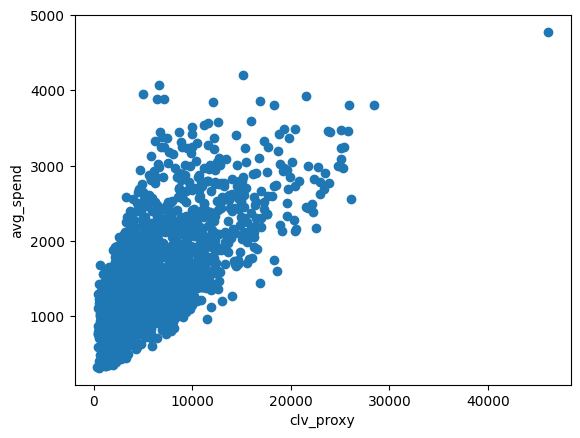

In [ ]:
plt.scatter(df["clv_proxy"], df["avg_spend"])
plt.xlabel("clv_proxy")
plt.ylabel("avg_spend")

Text(0, 0.5, 'frequency')

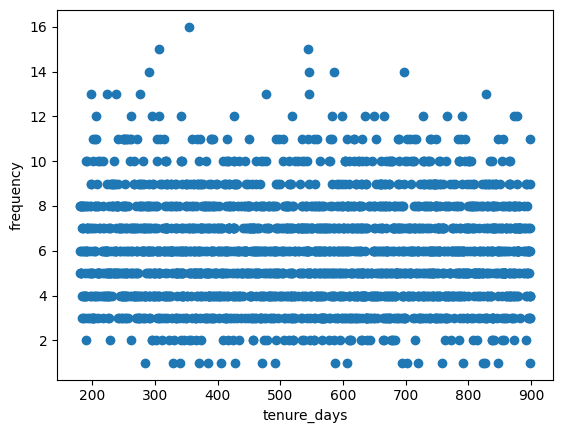

In [ ]:
plt.scatter(df["tenure_days"], df["frequency"])
plt.xlabel("tenure_days")
plt.ylabel("frequency")

In [ ]:
df.groupby("promo_segment_name")["clv_proxy"].quantile([0.25,0.5,0.75])


promo_segment_name              
ติดโปร มูลค่าออเดอร์ต่ำ     0.25     1820.9900
                            0.50     3096.5600
                            0.75     4615.8450
ติดโปร มูลค่าออเดอร์สูง     0.25     5041.5325
                            0.50     7441.0750
                            0.75    10658.4650
ไม่ติดโปร มูลค่าออเดอร์ต่ำ  0.25     1684.7500
                            0.50     2683.6700
                            0.75     4141.9500
ไม่ติดโปร มูลค่าออเดอร์สูง  0.25     4936.4800
                            0.50     8286.8000
                            0.75    12253.2650
ไม่ต้องรีบทำ campaign       0.25     2441.4600
                            0.50     3807.9400
                            0.75     5647.5475
Name: clv_proxy, dtype: float64

In [ ]:
df

,customer_id,region,customer_segment,discount_sensitivity,frequency,recency_days,tenure_days,monetary,avg_spend,churn_flag,...,longevity_score,fomo_score,longevity_segment,longevity_segment3,longevity_segment2,fomo_segment,discount_level,spend_level,promo_behavior,promo_segment_name
0,C00001,Central,High Activity,Low,8,158,389,9235.30,1154.41,0,...,0.420693,0.859383,High Longevity,High Longevity,Mid Longevity,High fomo,Low,Mid,Low_Mid,ไม่ต้องรีบทำ campaign
1,C00002,East,Mid Activity,Low,6,20,742,14275.56,2379.26,1,...,0.380685,0.889016,High Longevity,High Longevity,Mid Longevity,High fomo,Low,High,Low_High,ไม่ติดโปร มูลค่าออเดอร์สูง
2,C00003,South,Mid Activity,Low,5,7,297,5947.43,1189.49,0,...,0.292899,0.866030,Mid Longevity,Mid Longevity,Low Longevity,High fomo,Low,Mid,Low_Mid,ไม่ต้องรีบทำ campaign
3,C00004,South,Low Activity,Low,4,249,892,6167.41,1541.85,1,...,0.230602,0.837983,Low Longevity,Low Longevity,Low Longevity,High fomo,Low,High,Low_High,ไม่ติดโปร มูลค่าออเดอร์สูง
4,C00005,North,High Activity,Low,8,120,556,10749.66,1343.71,0,...,0.437599,0.870489,High Longevity,High Longevity,Mid Longevity,High fomo,Low,Mid,Low_Mid,ไม่ต้องรีบทำ campaign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2251,C02346,South,Power User,Low,9,9,326,32080.00,3564.44,0,...,0.521568,0.900225,High Longevity,High Longevity,Mid Longevity,High fomo,Low,High,Low_High,ไม่ติดโปร มูลค่าออเดอร์สูง
2252,C02347,South,Low Activity,Low,3,23,669,2299.13,766.38,0,...,0.196220,0.856574,Low Longevity,Low Longevity,Low Longevity,High fomo,Low,Low,Low_Low,ไม่ติดโปร มูลค่าออเดอร์ต่ำ
2253,C02348,Central,High Activity,Low,7,4,657,17705.80,2529.40,1,...,0.434647,0.897114,High Longevity,High Longevity,Mid Longevity,High fomo,Low,High,Low_High,ไม่ติดโปร มูลค่าออเดอร์สูง
2254,C02349,South,High Activity,High,8,40,338,10152.04,1269.01,0,...,0.386390,0.075471,High Longevity,High Longevity,Mid Longevity,Low fomo,High,Mid,High_Mid,ไม่ต้องรีบทำ campaign


In [ ]:
df.to_csv("abt_table2.csv")